# NexusTrace: M&A Intelligence (GraphRAG POC)

This notebook uses Neo4j Aura (cloud) so there is nothing to install or configure.
You just need your credentials file and an OpenAI key for the final LLM step.

---

**What we build, step by step:**
1. Connect to your Neo4j Aura cloud database
2. Load M&A data into the graph
3. Visualize the graph
4. Run multi-hop Cypher queries
5. Analyze the data with charts
6. Connect an LLM for natural language Q&A

---
## STEP 1 - Install Python Libraries

We only need the Python packages. No database installation required because Neo4j Aura is already running in the cloud.

In [31]:
!pip install -q neo4j pandas python-dotenv openai yfiles-jupyter-graphs
!pip install --upgrade -q kagglehub
print("All libraries installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 18.9 MB/s eta 0:00:00
All libraries installed


In [58]:
!pip install -q networkx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
print("Libraries ready")

Libraries ready


---
## STEP 2 - Upload Your Credentials File

Upload your `Neo4j-credentials.txt` file to Colab using the file panel on the left.

The file should contain these three lines:
```
NEO4J_URI=neo4j+s://xxxxxxxx.databases.neo4j.io
NEO4J_USERNAME=neo4j
NEO4J_PASSWORD=your-password-here
```

Once uploaded, run the cell below to connect.

In [60]:
import os
from dotenv import load_dotenv
from neo4j import GraphDatabase
from google.colab import userdata

# Load credentials from the file you uploaded
# Change the filename here if yours is named differently
# load_status = load_dotenv("Neo4j-credentials.txt")
# if not load_status:
#     raise RuntimeError("Credentials file not found. Make sure you uploaded Neo4j-credentials.txt")

URI      = userdata.get('NEO4J_URI')#os.getenv("NEO4J_URI")
USERNAME = userdata.get('NEO4J_USERNAME')#os.getenv("NEO4J_USERNAME")
PASSWORD = userdata.get('NEO4J_PASSWORD')#os.getenv("NEO4J_PASSWORD")

# Create the driver - this is your persistent connection to Aura
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

# Verify the connection is working before we do anything else
try:
    driver.verify_connectivity()
    print("Connection to Neo4j Aura established successfully")
except Exception as e:
    print(f"Connection failed: {e}")
    driver.close()

Connection to Neo4j Aura established successfully


---
## STEP 3 - Define the M&A Dataset

We use a small but realistic dataset to practice all GraphRAG patterns:
- 3 acquirers: Google, Microsoft, Apple
- 7 acquired companies across different industries
- 4 founders (including one serial founder to practice that query)

This is enough to explore every query type without noise.

In [61]:
import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("shivamb/company-acquisitions-7-top-companies")
print(f"Path to dataset files: {path}")

# List files in the downloaded directory to check contents
print(f"Files in downloaded directory: {os.listdir(path)}")

# Construct full path to the acquisition file
acquisition_file = os.path.join(path, "acquisitions_update_2021.csv")

# Load acquisition data and rename columns to match the notebook's expected schema
df_tx_raw = pd.read_csv(acquisition_file)
df_tx = df_tx_raw.rename(columns={
    'Parent Company': 'acquirer',
    'Acquired Company': 'acquired',
    'Acquisition Year': 'year',
    'Business': 'industry'
})

# Convert 'Acquisition Price' to numeric (billions USD) and handle missing values
df_tx['price_b'] = pd.to_numeric(
    df_tx_raw['Acquisition Price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
) / 1_000_000_000

print("\nTransactions loaded from Kaggle:")
print(df_tx.head())

# Founder relationships (re-using original dummy data as Kaggle dataset does not contain this)
founders = [
    {"founder": "Bill Gates",      "company": "Microsoft"},
    {"founder": "Larry Page",      "company": "Google"},
    {"founder": "Charles Ranlett Flint", "company": "IBM"},
    {"founder": "Bill Hewlett and David Packard", "company": "HP"},
    {"founder": "Steve Jobs",      "company": "Apple"},
    {"founder": "Jeff Bezos",      "company": "Amazon"},
    {"founder": "Mark Zuckerberg",  "company": "Facebook"},
    {"founder": "Jack Dorsey",     "company": "Twitter"},
    {"founder": "Pierre Omidyar",  "company": "eBay"},
    {"founder": "John Warnock and Charles Geschke", "company": "Adobe"},
    {"founder": "Ed Lambert",       "company": "Citrix"},
    {"founder": "Bob Young and Marc Ewing", "company": "Red Hat"},
    {"founder": "Mike Lazaridis and Douglas Fregin", "company": "BlackBerry"},
    {"founder": "Walt Disney",      "company": "Disney"}
]

df_founders = pd.DataFrame(founders)
print("\nFounder relationships (from original dummy data):")
print(df_founders.head())

Using Colab cache for faster access to the 'company-acquisitions-7-top-companies' dataset.
Path to dataset files: /kaggle/input/company-acquisitions-7-top-companies
Files in downloaded directory: ['acquisitions_update_2021.csv']

Transactions loaded from Kaggle:
   ID acquirer  year Acquisition Month               acquired  \
0   1    Apple  1988               Mar    Network Innovations   
1   2    Apple  1988               Jun  Orion Network Systems   
2   3    Apple  1988               Jun              Styleware   
3   4    Apple  1988               Jul        Nashoba Systems   
4   5    Apple  1989               Jan         Coral Software   

            industry Country Acquisition Price Category Derived Products  \
0           Software       -                 -        -                -   
1  Computer Software       -                 -        -                -   
2  Computer software       -                 -        -                -   
3  Computer software       -              

---
## STEP 4 - Load Data into Neo4j Aura

Key Cypher concepts in this cell:

- `MERGE` means create the node only if it does not already exist (prevents duplicates)
- `SET` attaches properties to a node (like columns in a table)
- `[:ACQUIRED_BY]` is a directed relationship (edge) with properties like year and price

The graph model here is:
`(Company) -[:ACQUIRED_BY]-> (Company)`
`(Person)  -[:FOUNDED]->     (Company)`

In [62]:
def load_transaction(tx, row):
    """Creates two Company nodes and an ACQUIRED_BY relationship between them."""
    tx.run("""
        MERGE (acquired:Company {name: $acquired})
        SET acquired.industry = $industry

        MERGE (acquirer:Company {name: $acquirer})
        SET acquirer.industry = 'BigTech'

        MERGE (acquired)-[:ACQUIRED_BY {year: $year, price_b: $price_b}]->(acquirer)
    """, **row)


def load_founder(tx, row):
    """Creates a Person node and a FOUNDED relationship to an existing Company node."""
    tx.run("""
        MERGE (p:Person {name: $founder})
        MERGE (c:Company {name: $company})
        MERGE (p)-[:FOUNDED]->(c)
    """, **row)


# Always clear first so re-running the notebook does not duplicate data
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Cleared existing graph data")

# Load all transactions, filtering out rows with NaN in price_b
with driver.session() as session:
    # Filter out rows where price_b is NaN because Neo4j MERGE does not support NaN in properties
    valid_df_tx = df_tx.dropna(subset=['price_b'])
    for _, row in valid_df_tx.iterrows():
        session.execute_write(load_transaction, row.to_dict())
    print(f"Loaded {len(valid_df_tx)} transactions (skipped {len(df_tx) - len(valid_df_tx)} with missing prices)")

# Load all founder relationships
with driver.session() as session:
    for _, row in df_founders.iterrows():
        session.execute_write(load_founder, row.to_dict())
    print(f"Loaded {len(df_founders)} founder relationships")

Cleared existing graph data
Loaded 383 transactions (skipped 1072 with missing prices)
Loaded 14 founder relationships


---
## STEP 5 - Verify What Is in the Graph

In [63]:
with driver.session() as session:
    total_nodes = session.run("MATCH (n) RETURN count(n) AS c").single()["c"]
    total_rels  = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()["c"]
    companies   = session.run("MATCH (c:Company) RETURN count(c) AS c").single()["c"]
    people      = session.run("MATCH (p:Person) RETURN count(p) AS c").single()["c"]

print(f"Total nodes      : {total_nodes}")
print(f"Total edges      : {total_rels}")
print(f"Company nodes    : {companies}")
print(f"Person nodes     : {people}")

Total nodes      : 413
Total edges      : 397
Company nodes    : 399
Person nodes     : 14


---
## STEP 6 - Visualize the Full Graph

Color coding:
- Blue  = BigTech acquirers (Google, Microsoft, Apple)
- Purple = AI companies
- Orange = People (founders)
- Green  = All other acquired companies

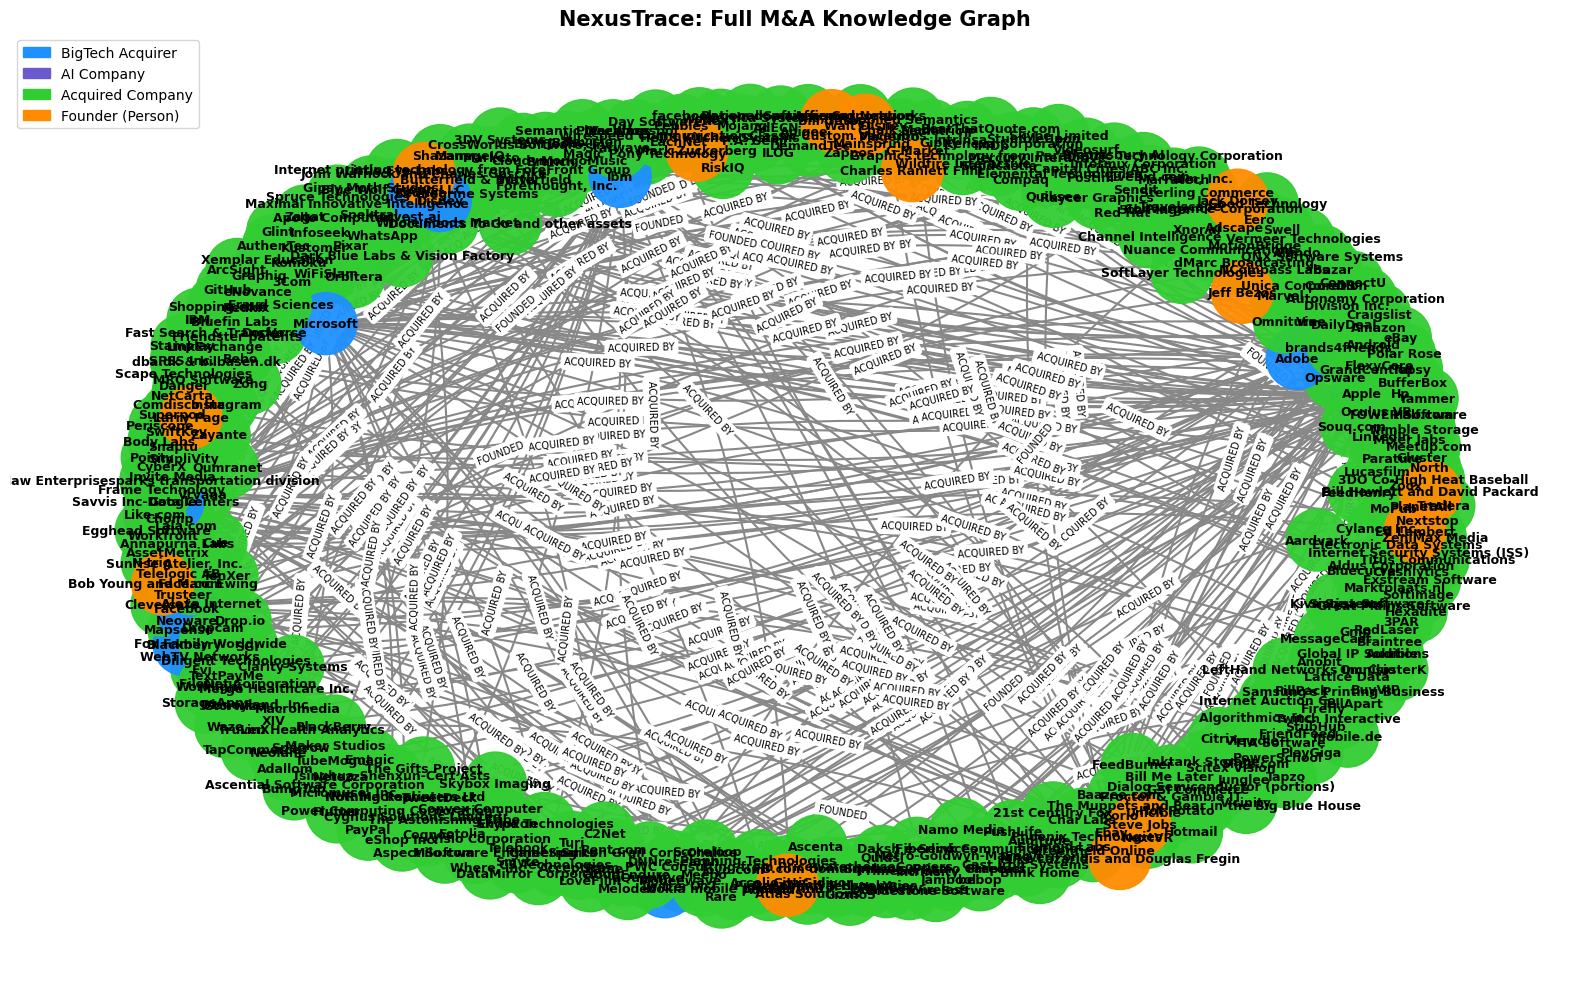

In [91]:
import networkx as nx
import matplotlib.patches as mpatches

# Return plain columns instead of result.graph()
with driver.session() as session:
    records = session.run("""
        MATCH (n)-[r]->(m)
        RETURN
            n.name          AS source,
            m.name          AS target,
            type(r)         AS rel_type,
            labels(n)[0]    AS source_label,
            labels(m)[0]    AS target_label,
            n.industry      AS source_industry,
            m.industry      AS target_industry
    """)
    rows = [dict(r) for r in records]

G = nx.DiGraph()
node_meta = {}

for row in rows:
    G.add_edge(row["source"], row["target"], rel=row["rel_type"])
    node_meta[row["source"]] = {"label": row["source_label"], "industry": row["source_industry"]}
    node_meta[row["target"]] = {"label": row["target_label"], "industry": row["target_industry"]}

def get_color(node):
    meta = node_meta.get(node, {})
    if meta.get("label") == "Person":
        return "#FF8C00"           # orange for founders
    if meta.get("industry") == "BigTech":
        return "#1E90FF"           # blue for acquirers
    if meta.get("industry") == "AI":
        return "#6A5ACD"           # purple for AI companies
    return "#32CD32"               # green for everything else

node_colors = [get_color(n) for n in G.nodes()]
edge_labels = {(u, v): data["rel"].replace("_", " ") for u, v, data in G.edges(data=True)}

fig, ax = plt.subplots(figsize=(16, 10))

pos = nx.spring_layout(G, seed=42, k=2.5)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.95, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color="#888888",
    arrows=True,
    arrowsize=20,
    width=1.5,
    connectionstyle="arc3,rad=0.1",
    ax=ax
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.35,
    ax=ax
)

legend_handles = [
    mpatches.Patch(color="#1E90FF", label="BigTech Acquirer"),
    mpatches.Patch(color="#6A5ACD", label="AI Company"),
    mpatches.Patch(color="#32CD32", label="Acquired Company"),
    mpatches.Patch(color="#FF8C00", label="Founder (Person)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=10)
ax.set_title("NexusTrace: Full M&A Knowledge Graph", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

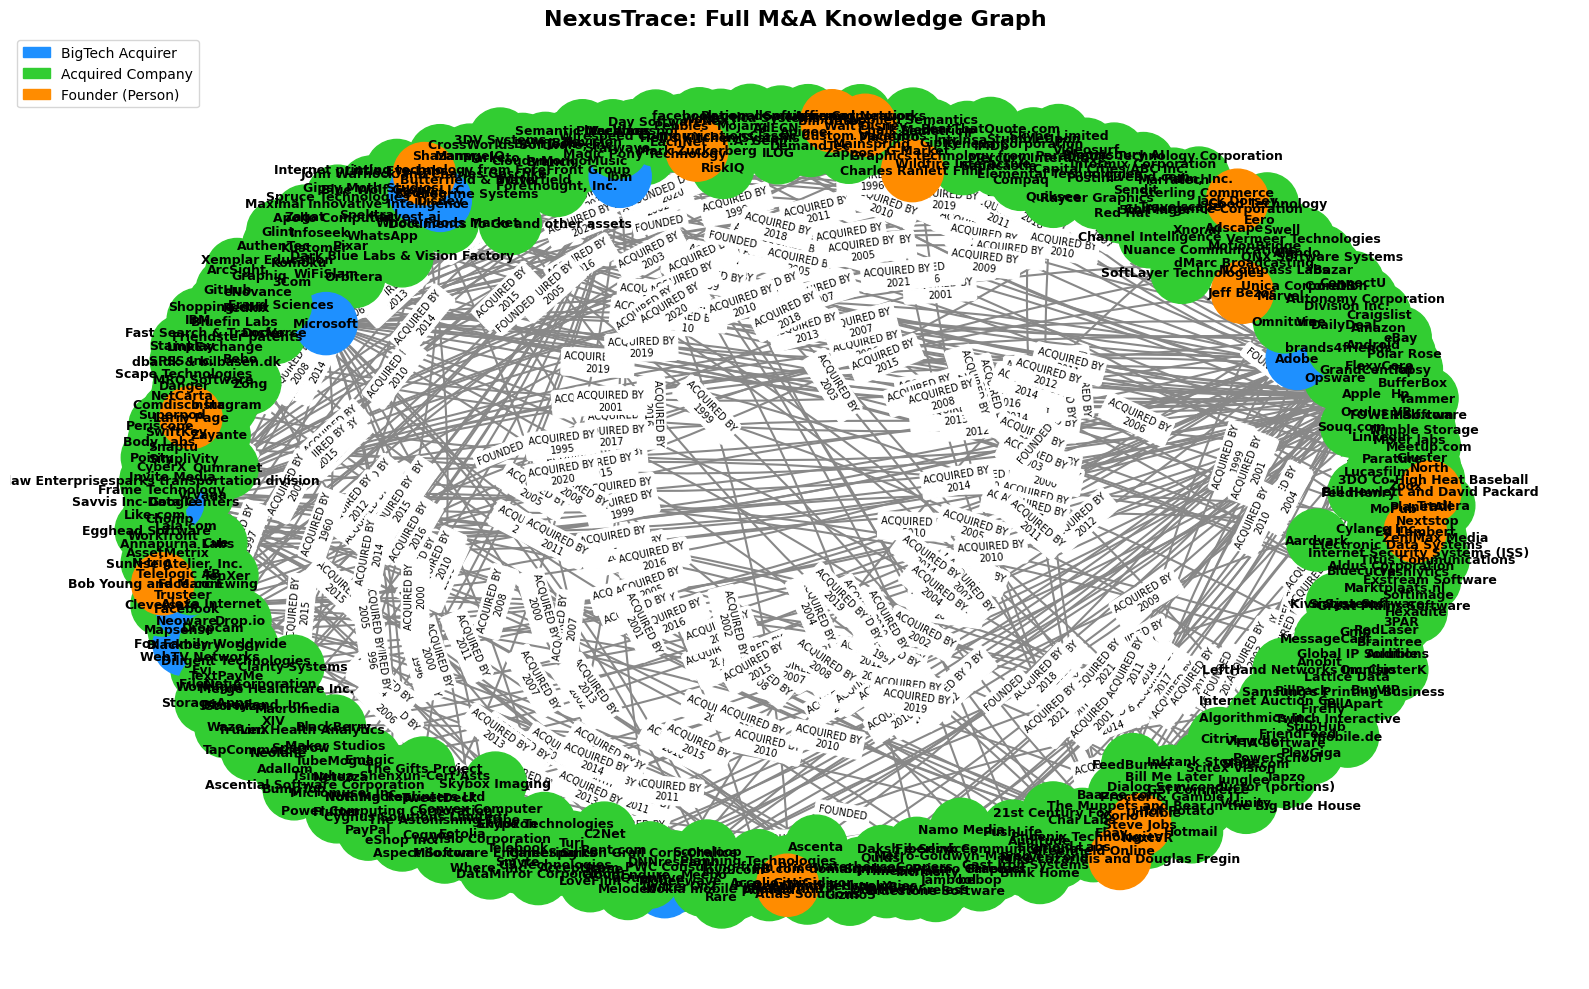

In [65]:
# Step 1 - Pull all nodes and edges from Neo4j
with driver.session() as session:
    records = session.run("""
        MATCH (n)-[r]->(m)
        RETURN
            n.name       AS source,
            m.name       AS target,
            type(r)      AS rel_type,
            r.year       AS year,
            labels(n)[0] AS source_label,
            labels(m)[0] AS target_label,
            n.industry   AS source_industry,
            m.industry   AS target_industry
    """)
    edges = [dict(r) for r in records]

# Step 2 - Build a NetworkX directed graph from the query results
G = nx.DiGraph()

# Track node metadata so we can color them correctly
node_meta = {}

for e in edges:
    G.add_edge(e["source"], e["target"], rel=e["rel_type"], year=e["year"])
    node_meta[e["source"]] = {"label": e["source_label"], "industry": e["source_industry"]}
    node_meta[e["target"]] = {"label": e["target_label"], "industry": e["target_industry"]}

# Step 3 - Assign a color to each node based on its type
def get_color(node):
    meta = node_meta.get(node, {})
    if meta.get("label") == "Person":
        return "#FF8C00"   # orange for founders
    if meta.get("industry") == "BigTech":
        return "#1E90FF"   # blue for acquirers
    return "#32CD32"        # green for acquired companies

node_colors = [get_color(n) for n in G.nodes()]

# Step 4 - Build edge labels (show relationship type + year where available)
edge_labels = {}
for u, v, data in G.edges(data=True):
    label = data["rel"].replace("_", " ")
    if data.get("year"):
        label += f"\n{data['year']}"
    edge_labels[(u, v)] = label

# Step 5 - Draw the graph
fig, ax = plt.subplots(figsize=(16, 10))

# spring_layout spreads nodes out based on connection density
pos = nx.spring_layout(G, seed=42, k=2.5)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color="#888888",
    arrows=True,
    arrowsize=20,
    width=1.5,
    connectionstyle="arc3,rad=0.1",
    ax=ax
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.35,
    ax=ax
)

# Legend
legend_handles = [
    mpatches.Patch(color="#1E90FF", label="BigTech Acquirer"),
    mpatches.Patch(color="#32CD32", label="Acquired Company"),
    mpatches.Patch(color="#FF8C00", label="Founder (Person)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=10)

ax.set_title("NexusTrace: Full M&A Knowledge Graph", fontsize=16, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## STEP 7 - Basic Cypher Queries (Single-Hop Lookups)

These are straightforward SELECT-style queries.
One relationship traversal per query.

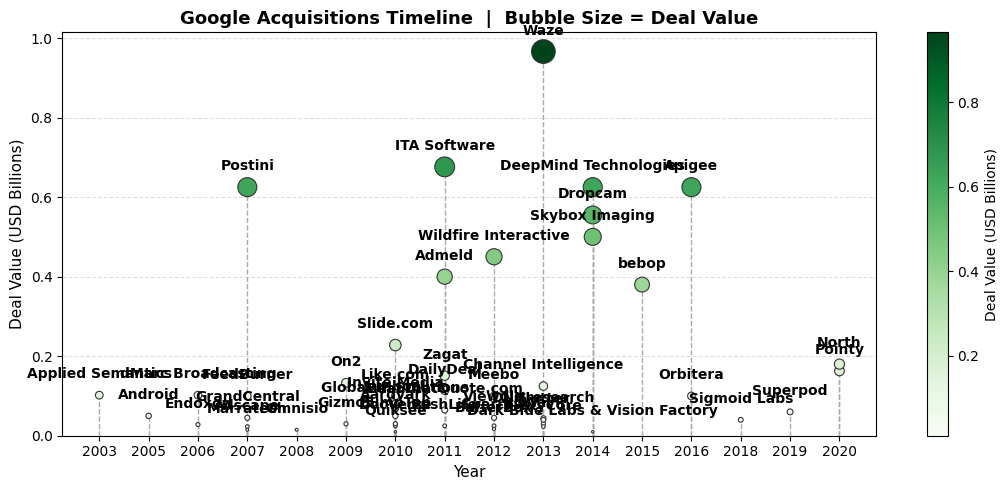

In [90]:
with driver.session() as session:
    results = session.run("""
        MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company {name: 'Google'})
        RETURN c.name AS company, r.year AS year, r.price_b AS price_b
        ORDER BY r.year
    """)
    data = [dict(r) for r in results]

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(11, 5))

# Scatter where y = deal value and x = year, sized by deal value
scatter = ax.scatter(
    df["year"], df["price_b"],
    s=df["price_b"] * 300,
    c=df["price_b"],
    cmap="Greens",
    edgecolors="#333333",
    linewidths=0.8,
    zorder=3
)

# Label each dot with the company name
for _, row in df.iterrows():
    ax.annotate(
        row["company"],
        xy=(row["year"], row["price_b"]),
        xytext=(0, 12), textcoords="offset points",
        ha="center", fontsize=10, fontweight="bold"
    )

# Thin vertical line down from each dot to zero for readability
for _, row in df.iterrows():
    ax.vlines(row["year"], 0, row["price_b"], colors="#aaaaaa", linewidth=1, linestyle="--")

plt.colorbar(scatter, ax=ax, label="Deal Value (USD Billions)")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Deal Value (USD Billions)", fontsize=11)
ax.set_title("Google Acquisitions Timeline  |  Bubble Size = Deal Value", fontsize=13, fontweight="bold")
ax.set_xticks(df["year"].unique())
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

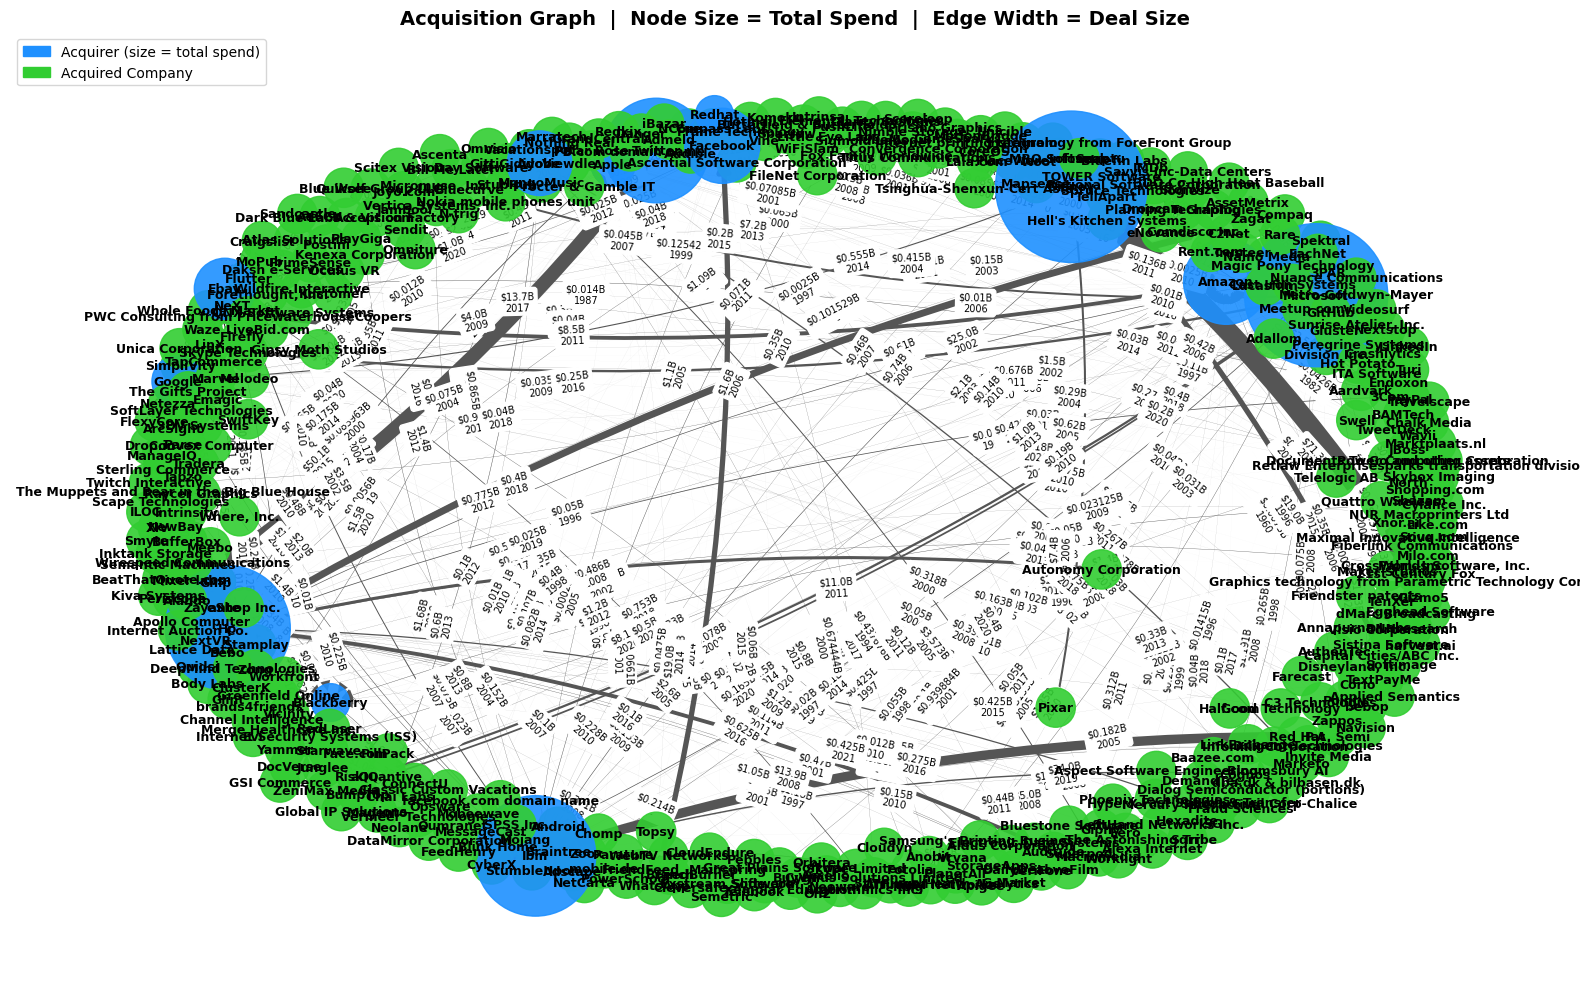

In [67]:
# Pull only acquisition edges with price data
with driver.session() as session:
    records = session.run("""
        MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company)
        RETURN c.name AS acquired, a.name AS acquirer, r.price_b AS price_b, r.year AS year
    """)
    acq_edges = [dict(r) for r in records]

# Build a weighted directed graph
G2 = nx.DiGraph()

# Track total spend per acquirer for node sizing
acquirer_spend = {}

for e in acq_edges:
    G2.add_edge(e["acquired"], e["acquirer"], weight=e["price_b"], year=e["year"])
    acquirer_spend[e["acquirer"]] = acquirer_spend.get(e["acquirer"], 0) + e["price_b"]

# Node sizes: acquirers scale with spend, acquired companies are fixed
ACQUIRERS = set(acquirer_spend.keys())
node_sizes = []
for n in G2.nodes():
    if n in ACQUIRERS:
        node_sizes.append(500 + acquirer_spend[n] * 100)   # bigger = more spend
    else:
        node_sizes.append(800)

node_colors2 = ["#1E90FF" if n in ACQUIRERS else "#32CD32" for n in G2.nodes()]

# Edge widths scale with deal size
edge_widths = [G2[u][v]["weight"] * 0.2 for u, v in G2.edges()]
edge_labels2 = {(u, v): f"${G2[u][v]['weight']}B\n{G2[u][v]['year']}" for u, v in G2.edges()}

fig, ax = plt.subplots(figsize=(16, 10))

pos2 = nx.spring_layout(G2, seed=7, k=3.0)

nx.draw_networkx_nodes(G2, pos2, node_color=node_colors2, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G2, pos2, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G2, pos2,
    width=edge_widths,
    edge_color="#555555",
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08",
    ax=ax
)
nx.draw_networkx_edge_labels(
    G2, pos2,
    edge_labels=edge_labels2,
    font_size=7,
    label_pos=0.3,
    ax=ax
)

legend_handles2 = [
    mpatches.Patch(color="#1E90FF", label="Acquirer (size = total spend)"),
    mpatches.Patch(color="#32CD32", label="Acquired Company"),
]
ax.legend(handles=legend_handles2, loc="upper left", fontsize=10)

ax.set_title("Acquisition Graph  |  Node Size = Total Spend  |  Edge Width = Deal Size", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [68]:
# from google.colab import output
# output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [69]:
from google.colab import output
output.disable_custom_widget_manager()

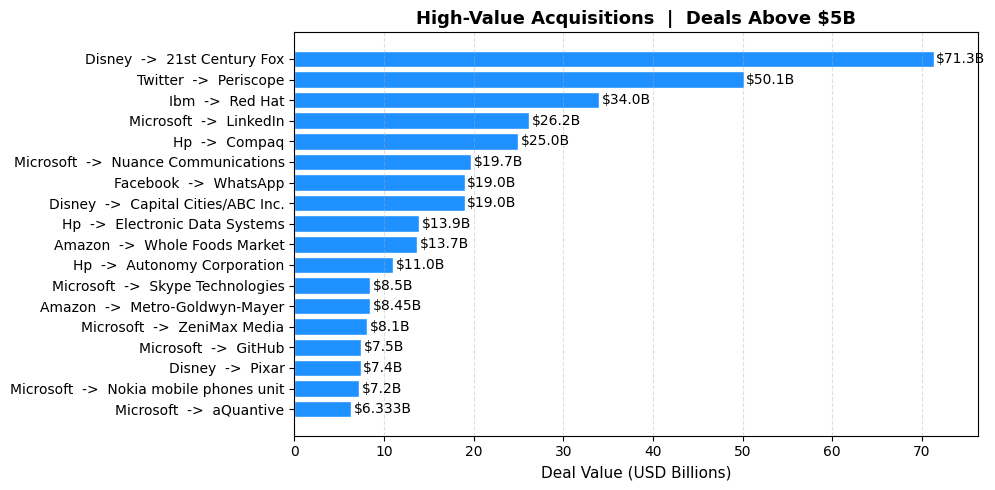

In [87]:
with driver.session() as session:
    results = session.run("""
        MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company)
        WHERE r.price_b > 5
        RETURN a.name AS acquirer, c.name AS target, r.price_b AS price_b
        ORDER BY r.price_b DESC
    """)
    data = [dict(r) for r in results]

df = pd.DataFrame(data)

# Label combines acquirer + target so each bar is self-explanatory
df["label"] = df["acquirer"] + "  ->  " + df["target"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df["label"], df["price_b"], color="#1E90FF", edgecolor="white")

# Print the value at the end of each bar
for bar, val in zip(bars, df["price_b"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"${val}B", va="center", fontsize=10)

ax.set_xlabel("Deal Value (USD Billions)", fontsize=11)
ax.set_title("High-Value Acquisitions  |  Deals Above $5B", fontsize=13, fontweight="bold")
ax.invert_yaxis()   # largest deal at the top
ax.set_xlim(0, df["price_b"].max() + 5)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

---
## STEP 8 - Multi-Hop Queries (The GraphRAG Superpower)

Standard search engines cannot do this. We cross two relationship types in one query.

Pattern we use:
`(Person)-[:FOUNDED]->(Company)-[:ACQUIRED_BY]->(BigTech)`

This answers questions that require connecting three separate data points simultaneously.

In [89]:
# Which founders had their companies acquired by Google?
# This crosses the FOUNDED and ACQUIRED_BY edges in one query
with driver.session() as session:
    results = session.run("""
        MATCH (p:Person)-[:FOUNDED]->(c:Company)-[r:ACQUIRED_BY]->(a:Company {name: 'Google'})
        RETURN p.name AS founder, c.name AS company, r.price_b AS exit_b
    """)
    print("Founders with Google exits:")
    for row in results:
        print(f"  {row['founder']}  founded  {row['company']}  ->  exited at ${row['exit_b']}B")

Founders with Google exits:


In [73]:
# Find serial founders (people who founded more than one company)
# WITH + count() is how Cypher does GROUP BY
with driver.session() as session:
    results = session.run("""
        MATCH (p:Person)-[:FOUNDED]->(c:Company)
        WITH p, count(c) AS num_founded, collect(c.name) AS companies
        WHERE num_founded > 1
        RETURN p.name AS founder, num_founded, companies
    """)
    print("Serial founders:")
    for row in results:
        print(f"  {row['founder']}  |  {row['num_founded']} companies  |  {row['companies']}")

Serial founders:


In [74]:
# Find sibling companies - two companies acquired by the same parent
# Pattern: (c1)-[:ACQUIRED_BY]->(parent)<-[:ACQUIRED_BY]-(c2)
# c1.name < c2.name prevents showing each pair twice
with driver.session() as session:
    results = session.run("""
        MATCH (c1:Company)-[:ACQUIRED_BY]->(parent:Company)<-[:ACQUIRED_BY]-(c2:Company)
        WHERE c1.name < c2.name
        RETURN parent.name AS parent, c1.name AS sibling_1, c2.name AS sibling_2
        ORDER BY parent.name, sibling_1
    """)
    print("Sibling companies (same acquirer):")
    for row in results:
        print(f"  Under {row['parent']}:  {row['sibling_1']}  and  {row['sibling_2']}")

Streaming output truncated to the last 5000 lines.
  Under Ebay:  Half.com  and  StumbleUpon
  Under Ebay:  Half.com  and  StubHub
  Under Ebay:  Half.com  and  Meetup.com
  Under Ebay:  Half.com  and  dba.dk & bilbasen.dk
  Under Ebay:  Half.com  and  Magento
  Under Ebay:  Half.com  and  mobile.de
  Under Ebay:  Half.com  and  Marktplaats.nl
  Under Ebay:  Half.com  and  Rent.com
  Under Ebay:  Half.com  and  Shopping.com
  Under Ebay:  Half.com  and  Skype Limited
  Under Ebay:  Half.com  and  Tradera
  Under Ebay:  Half.com  and  RedLaser
  Under Ebay:  Half.com  and  Milo.com
  Under Ebay:  Half.com  and  brands4friends
  Under Ebay:  Half.com  and  Where, Inc.
  Under Ebay:  Half.com  and  Zong
  Under Ebay:  Half.com  and  Internet Auction Co.
  Under Ebay:  Half.com  and  iBazar
  Under Ebay:  Half.com  and  PayPal
  Under Ebay:  Internet Auction Co.  and  iBazar
  Under Ebay:  Internet Auction Co.  and  PayPal
  Under Ebay:  Internet Auction Co.  and  mobile.de
  Under Ebay:  

/tmp/ipython-input-762/560246154.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


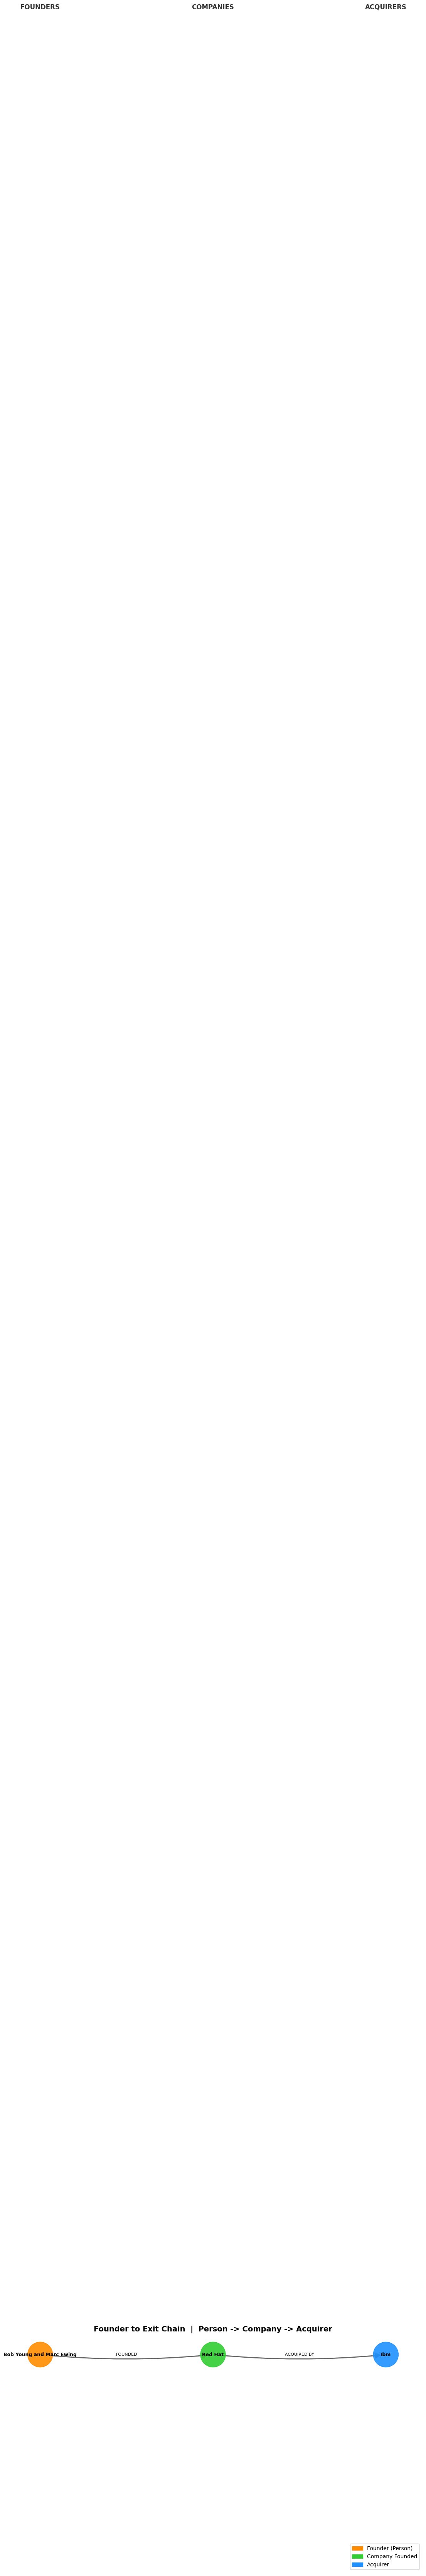

In [75]:
# Pull the full founder chain: Person -> Company -> Acquirer
with driver.session() as session:
    records = session.run("""
        MATCH (p:Person)-[:FOUNDED]->(c:Company)-[:ACQUIRED_BY]->(a:Company)
        RETURN p.name AS founder, c.name AS company, a.name AS acquirer
    """)
    chain_data = [dict(r) for r in records]

G3 = nx.DiGraph()

for row in chain_data:
    G3.add_edge(row["founder"],  row["company"],  rel="FOUNDED")
    G3.add_edge(row["company"],  row["acquirer"], rel="ACQUIRED BY")

# Classify each node so we can assign positions in a left-to-right layout
founders_set  = {r["founder"]  for r in chain_data}
companies_set = {r["company"]  for r in chain_data}
acquirers_set = {r["acquirer"] for r in chain_data}

# Manual left-to-right positions so the flow is readable
# Founders on left, companies in middle, acquirers on right
pos3 = {}
for i, n in enumerate(sorted(founders_set)):
    pos3[n] = (0, i * 1.5)
for i, n in enumerate(sorted(companies_set)):
    pos3[n] = (2, i * 1.5)
for i, n in enumerate(sorted(acquirers_set)):
    pos3[n] = (4, i * 1.5)

node_colors3 = []
for n in G3.nodes():
    if n in founders_set:  node_colors3.append("#FF8C00")
    elif n in acquirers_set: node_colors3.append("#1E90FF")
    else: node_colors3.append("#32CD32")

edge_labels3 = {(u, v): data["rel"] for u, v, data in G3.edges(data=True)}

fig, ax = plt.subplots(figsize=(14, 8))

nx.draw_networkx_nodes(G3, pos3, node_color=node_colors3, node_size=2200, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G3, pos3, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G3, pos3,
    edge_color="#666666",
    arrows=True,
    arrowsize=22,
    width=2,
    connectionstyle="arc3,rad=0.05",
    ax=ax
)
nx.draw_networkx_edge_labels(G3, pos3, edge_labels=edge_labels3, font_size=8, ax=ax)

# Column header labels
y_top = max(p[1] for p in pos3.values()) + 1.0
for x, label in [(0, "FOUNDERS"), (2, "COMPANIES"), (4, "ACQUIRERS")]:
    ax.text(x, y_top, label, ha="center", fontsize=12, fontweight="bold", color="#333333")

legend_handles3 = [
    mpatches.Patch(color="#FF8C00", label="Founder (Person)"),
    mpatches.Patch(color="#32CD32", label="Company Founded"),
    mpatches.Patch(color="#1E90FF", label="Acquirer"),
]
ax.legend(handles=legend_handles3, loc="lower right", fontsize=10)

ax.set_title("Founder to Exit Chain  |  Person -> Company -> Acquirer", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## STEP 9 - Aggregate Analysis with Charts

This mimics what GraphRAG community detection does at scale.
We are summarizing groups of connected nodes.

      acquirer  num_deals  total_spend_b
0       Disney         14          113.9
1    Microsoft         61          101.3
2           Hp         34           76.0
3          Ibm         38           70.3
4      Twitter         14           51.7
5       Amazon         39           32.8
6     Facebook         26           24.3
7        Adobe         14           16.7
8         Ebay         32           14.4
9       Google         49            8.5
10       Apple         39            5.2
11  Blackberry          8            2.4
12      Redhat         15            2.4


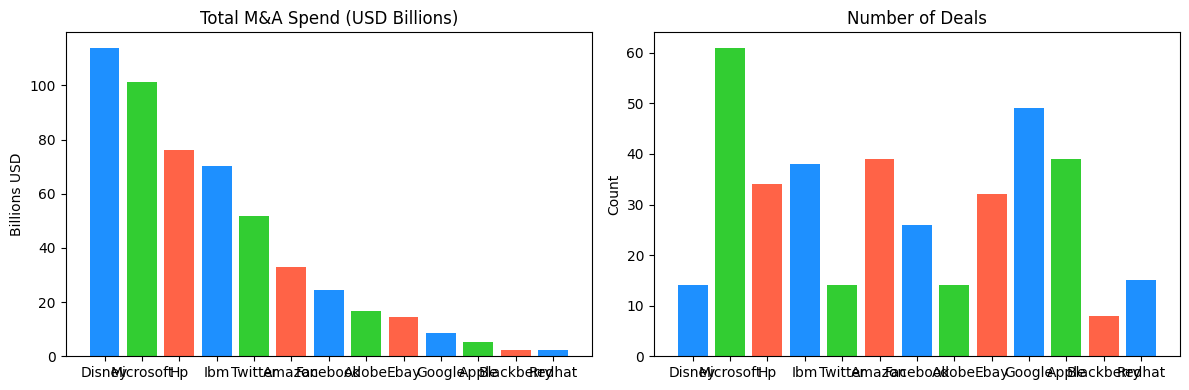

In [76]:
import matplotlib.pyplot as plt

# Total spend and deal count per acquirer
with driver.session() as session:
    results = session.run("""
        MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company)
        RETURN a.name AS acquirer,
               count(c) AS num_deals,
               round(sum(r.price_b) * 10) / 10 AS total_spend_b
        ORDER BY total_spend_b DESC
    """)
    summary_data = [dict(row) for row in results]

df_summary = pd.DataFrame(summary_data)
print(df_summary)

colors = ["#1E90FF", "#32CD32", "#FF6347"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_summary["acquirer"], df_summary["total_spend_b"], color=colors)
axes[0].set_title("Total M&A Spend (USD Billions)")
axes[0].set_ylabel("Billions USD")

axes[1].bar(df_summary["acquirer"], df_summary["num_deals"], color=colors)
axes[1].set_title("Number of Deals")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

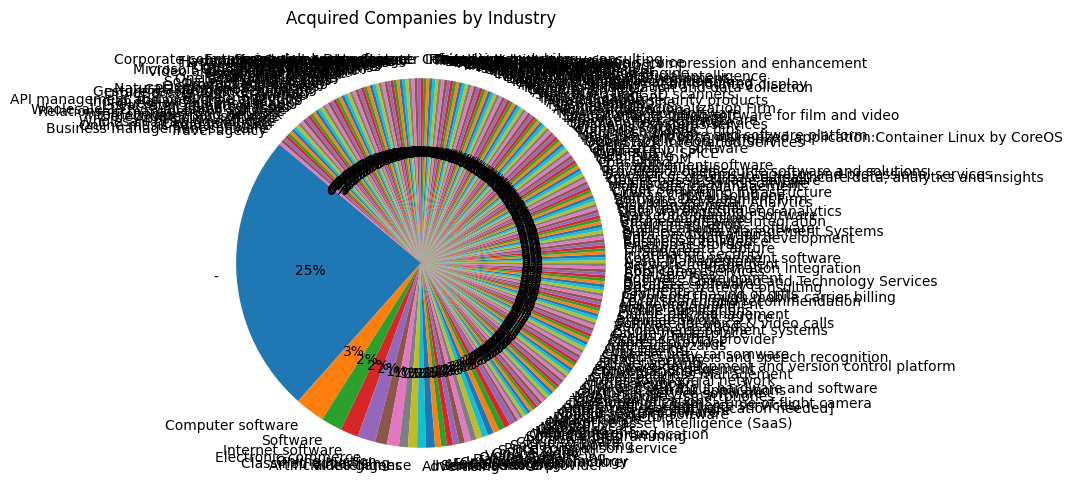

In [77]:
# Industry breakdown of acquired companies
with driver.session() as session:
    results = session.run("""
        MATCH (c:Company)-[:ACQUIRED_BY]->()
        RETURN c.industry AS industry, count(*) AS count
        ORDER BY count DESC
    """)
    ind_data = [dict(row) for row in results]

df_ind = pd.DataFrame(ind_data)

plt.figure(figsize=(6, 6))
plt.pie(df_ind["count"], labels=df_ind["industry"], autopct="%1.0f%%", startangle=140)
plt.title("Acquired Companies by Industry")
plt.show()

---
## STEP 10 - Visualize a Subgraph (Local Context Retrieval)

This is how GraphRAG retrieves 'local context' for a query.
Instead of the whole graph, we zoom into just the 2-hop neighborhood of one company.

Change `Google` to `Microsoft` or `Apple` to explore different neighborhoods.

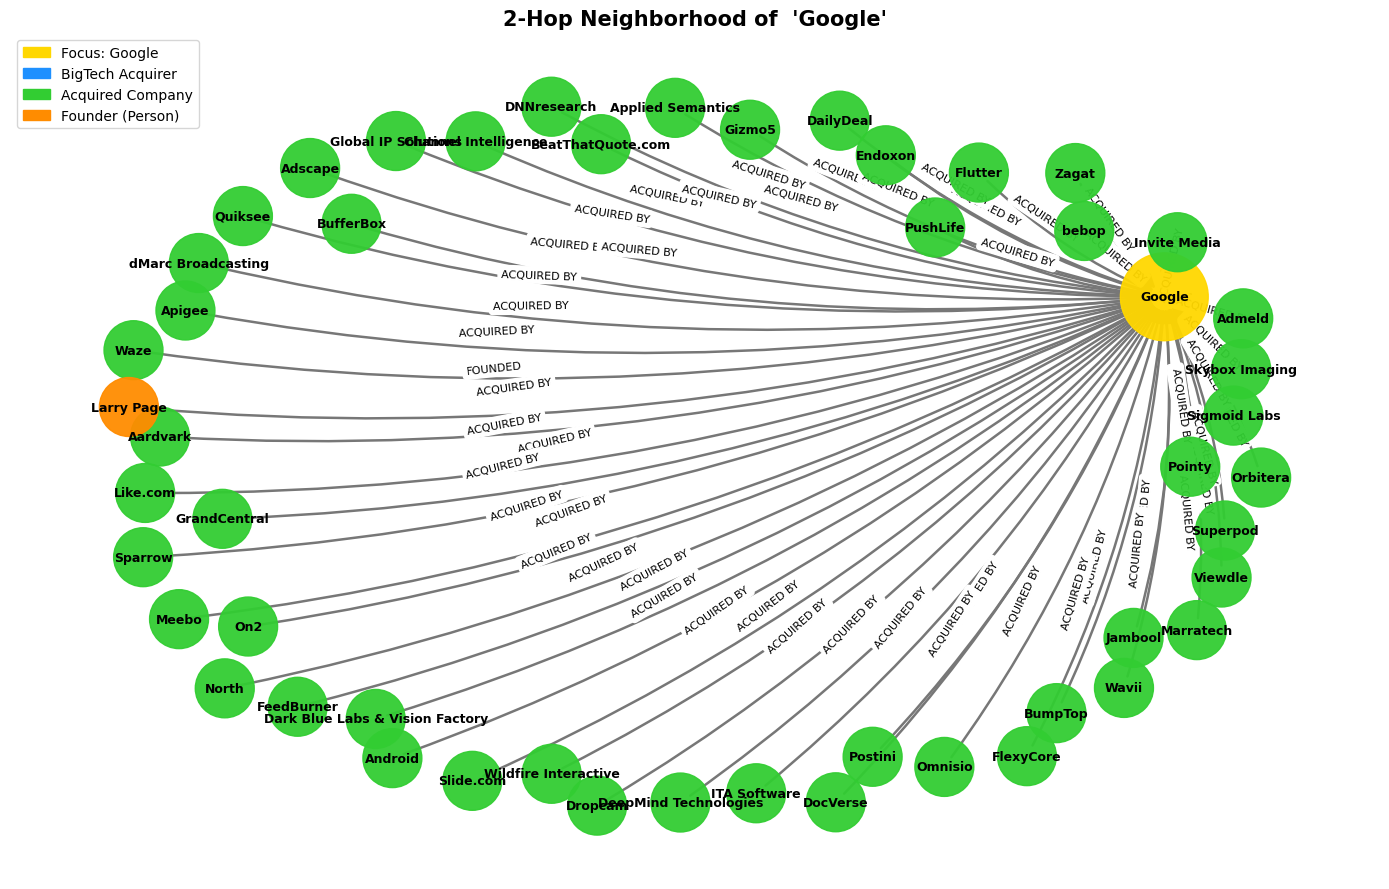

In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FOCUS_COMPANY = "Google"   # Change this to explore other neighborhoods

# Pull the 2-hop neighborhood from Neo4j as raw rows
with driver.session() as session:
    records = session.run("""
        MATCH path = (n)-[*1..2]-(a:Company {name: $name})
        UNWIND relationships(path) AS r
        RETURN
            startNode(r).name       AS source,
            endNode(r).name         AS target,
            type(r)                 AS rel_type,
            labels(startNode(r))[0] AS source_label,
            labels(endNode(r))[0]   AS target_label,
            startNode(r).industry   AS source_industry,
            endNode(r).industry     AS target_industry
    """, name=FOCUS_COMPANY)
    rows = [dict(r) for r in records]

# Build the NetworkX graph from those rows
G = nx.DiGraph()
node_meta = {}

for row in rows:
    G.add_edge(row["source"], row["target"], rel=row["rel_type"])
    node_meta[row["source"]] = {"label": row["source_label"], "industry": row["source_industry"]}
    node_meta[row["target"]] = {"label": row["target_label"], "industry": row["target_industry"]}

# Assign colors - focus company gets a special highlight
def get_color(node):
    if node == FOCUS_COMPANY:
        return "#FFD700"           # gold for the focus node
    meta = node_meta.get(node, {})
    if meta.get("label") == "Person":
        return "#FF8C00"           # orange for founders
    if meta.get("industry") == "BigTech":
        return "#1E90FF"           # blue for acquirers
    return "#32CD32"               # green for acquired companies

node_colors = [get_color(n) for n in G.nodes()]

# Make the focus company node larger so it stands out
node_sizes = [4000 if n == FOCUS_COMPANY else 1800 for n in G.nodes()]

# Edge labels show the relationship type
edge_labels = {(u, v): data["rel"].replace("_", " ") for u, v, data in G.edges(data=True)}

# Draw
fig, ax = plt.subplots(figsize=(14, 9))

# spring_layout with a fixed seed keeps the layout stable across runs
pos = nx.spring_layout(G, seed=42, k=2.8)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.95, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color="#777777",
    arrows=True,
    arrowsize=20,
    width=1.8,
    connectionstyle="arc3,rad=0.1",
    ax=ax
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.35,
    ax=ax
)

legend_handles = [
    mpatches.Patch(color="#FFD700", label=f"Focus: {FOCUS_COMPANY}"),
    mpatches.Patch(color="#1E90FF", label="BigTech Acquirer"),
    mpatches.Patch(color="#32CD32", label="Acquired Company"),
    mpatches.Patch(color="#FF8C00", label="Founder (Person)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=10)
ax.set_title(f"2-Hop Neighborhood of  '{FOCUS_COMPANY}'", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

      acquirer  num_deals  total_spend_b
0       Disney         14          113.9
1    Microsoft         61          101.3
2           Hp         34           76.0
3          Ibm         38           70.3
4      Twitter         14           51.7
5       Amazon         39           32.8
6     Facebook         26           24.3
7        Adobe         14           16.7
8         Ebay         32           14.4
9       Google         49            8.5
10       Apple         39            5.2
11  Blackberry          8            2.4
12      Redhat         15            2.4


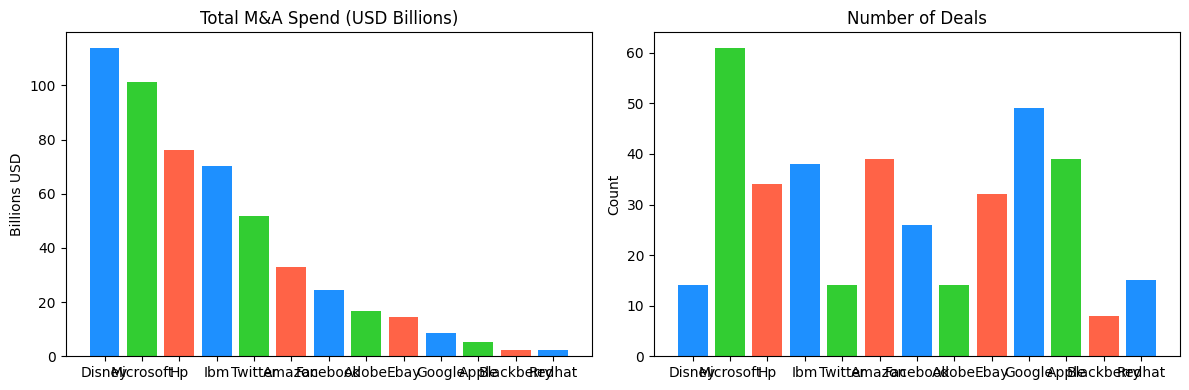

In [86]:
import matplotlib.pyplot as plt

# Total spend and deal count per acquirer
with driver.session() as session:
    results = session.run("""
        MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company)
        RETURN a.name AS acquirer,
               count(c) AS num_deals,
               round(sum(r.price_b) * 10) / 10 AS total_spend_b
        ORDER BY total_spend_b DESC
    """)
    summary_data = [dict(row) for row in results]

df_summary = pd.DataFrame(summary_data)
print(df_summary)

colors = ["#1E90FF", "#32CD32", "#FF6347"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_summary["acquirer"], df_summary["total_spend_b"], color=colors)
axes[0].set_title("Total M&A Spend (USD Billions)")
axes[0].set_ylabel("Billions USD")

axes[1].bar(df_summary["acquirer"], df_summary["num_deals"], color=colors)
axes[1].set_title("Number of Deals")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## STEP 11 - Connect an LLM for Natural Language Q&A

This is the Graph-Augmented Generation step.

The flow is:
1. User asks a question about a company
2. We fetch that company's graph neighborhood as structured text
3. We inject that text into the LLM prompt as context
4. The LLM answers using only what the graph contains

This is better than RAG because the context is already structured and pre-connected.
The LLM does not need to figure out relationships - the graph already encoded them.

Support for third party widgets will remain active for the duration of the session. To disable support:

In [54]:
from google.colab import output
output.disable_custom_widget_manager()

In [55]:
# Set your OpenAI API key here
# Or use: from google.colab import userdata; OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY5')  # Replace with your key

In [56]:
from openai import OpenAI

llm = OpenAI(api_key=OPENAI_API_KEY)


def build_context(company_name):
    """
    Queries the graph for everything connected to a company within 2 hops.
    Returns a plain text block we can paste into an LLM prompt.
    """
    with driver.session() as session:

        # What did this company acquire?
        acquisitions = session.run("""
            MATCH (c:Company)-[r:ACQUIRED_BY]->(a:Company {name: $name})
            RETURN c.name AS target, r.year AS year, r.price_b AS price, c.industry AS industry
        """, name=company_name)
        acq_lines = [
            f"{r['target']} ({r['industry']}, {r['year']}, ${r['price']}B)"
            for r in acquisitions
        ]

        # Founders connected via acquisition chain
        founders = session.run("""
            MATCH (p:Person)-[:FOUNDED]->(c:Company)-[:ACQUIRED_BY]->(a:Company {name: $name})
            RETURN p.name AS founder, c.name AS company
        """, name=company_name)
        founder_lines = [f"{r['founder']} founded {r['company']}" for r in founders]

    context  = f"Company: {company_name}\n"
    context += f"Acquisitions: {', '.join(acq_lines) if acq_lines else 'None on record'}\n"
    context += f"Connected founders: {', '.join(founder_lines) if founder_lines else 'None on record'}\n"
    return context


def ask(question, company_name):
    """
    Fetches graph context for the company and sends it with the question to the LLM.
    """
    context = build_context(company_name)

    prompt = f"""You are an M&A intelligence analyst.
Use ONLY the graph data below to answer the question.
If the data does not contain the answer, say so clearly.

GRAPH DATA:
{context}

QUESTION: {question}"""

    response = llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300
    )
    return response.choices[0].message.content


# Try it - change the question or company_name to explore
answer = ask(
    question="Which AI companies did this acquirer buy and who founded them?",
    company_name="Google"
)
print(answer)

The acquirer Google bought the following AI companies:

1. DeepMind Technologies (2014, $0.625B)
2. Dark Blue Labs & Vision Factory (2014, $0.01B)

However, there are no records of the founders of these companies.


---
## STEP 12 - Clean Up (Close the Driver)

Always close the driver when you are done to release the connection.

In [57]:
driver.close()
print("Connection closed")

Connection closed


---
## Recap

- Step 1     : Installed only Python packages (no local database needed)
- Steps 2-3  : Connected to Neo4j Aura using your credentials file
- Steps 4-5  : Loaded M&A data using MERGE (nodes + relationships)
- Steps 6-7  : Visualized the full graph with color-coded nodes
- Step 8     : Ran multi-hop Cypher queries that standard search cannot do
- Steps 9-10 : Aggregated the graph into charts and zoomed into subgraphs
- Step 11    : Plugged in an LLM to answer natural language questions using graph context

The core idea: the graph gives the LLM structured, pre-connected context instead of unrelated text chunks.